In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests
from nilearn import datasets, plotting


def fdr_significant_qcfc(
    qcfc_matrix,
    p_matrix,
    alpha=0.05
):
    """
    Apply BH-FDR to the unique upper-triangle QC-FC edges.

    Returns
    -------
    significant_r_matrix : matrix containing significant QC-FC r values
    binary_matrix        : 1 for significant edges, otherwise 0
    significant_mask    : Boolean symmetric matrix
    q_matrix             : symmetric matrix of FDR-adjusted p-values
    """

    qcfc_matrix = np.asarray(qcfc_matrix, dtype=float)
    p_matrix = np.asarray(p_matrix, dtype=float)

    if qcfc_matrix.shape != p_matrix.shape:
        raise ValueError("QC-FC and p-value matrices must have the same shape.")

    if qcfc_matrix.ndim != 2:
        raise ValueError("Input must be a square matrix.")

    n_rois = qcfc_matrix.shape[0]

    if qcfc_matrix.shape[1] != n_rois:
        raise ValueError("Input must be a square matrix.")

    # Extract each undirected edge only once
    upper_i, upper_j = np.triu_indices(n_rois, k=1)

    edge_p = p_matrix[upper_i, upper_j]
    edge_r = qcfc_matrix[upper_i, upper_j]

    # Handle possible NaN values
    valid = np.isfinite(edge_p) & np.isfinite(edge_r)

    reject = np.zeros(len(edge_p), dtype=bool)
    q_values = np.full(len(edge_p), np.nan)

    reject_valid, q_valid, _, _ = multipletests(
        edge_p[valid],
        alpha=alpha,
        method="fdr_bh"
    )

    reject[valid] = reject_valid
    q_values[valid] = q_valid

    # Matrices for plotting and saving
    significant_r_matrix = np.zeros((n_rois, n_rois))
    binary_matrix = np.zeros((n_rois, n_rois))
    significant_mask = np.zeros((n_rois, n_rois), dtype=bool)
    q_matrix = np.full((n_rois, n_rois), np.nan)

    significant_r_matrix[upper_i, upper_j] = np.where(
        reject, edge_r, 0
    )
    binary_matrix[upper_i, upper_j] = reject.astype(float)
    significant_mask[upper_i, upper_j] = reject
    q_matrix[upper_i, upper_j] = q_values

    # Make matrices symmetric
    significant_r_matrix += significant_r_matrix.T
    binary_matrix += binary_matrix.T
    significant_mask |= significant_mask.T

    q_matrix[upper_j, upper_i] = q_values
    np.fill_diagonal(q_matrix, np.nan)

    return (
        significant_r_matrix,
        binary_matrix,
        significant_mask,
        q_matrix
    )

In [2]:
qcfc_matrix = np.load("/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/faizan_motion_correction_dataset/roi_timeseries_hfiltered_videos/qc_fc_2mo_firstrun/qc_fc_r.npy")
p_matrix = np.load("/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/faizan_motion_correction_dataset/roi_timeseries_hfiltered_videos/qc_fc_2mo_firstrun/qc_fc_p.npy")

(
    significant_r_matrix,
    binary_significant_matrix,
    significant_mask,
    q_matrix
) = fdr_significant_qcfc(
    qcfc_matrix=qcfc_matrix,
    p_matrix=p_matrix,
    alpha=0.05
)

In [3]:
n_rois = qcfc_matrix.shape[0]
total_edges = n_rois * (n_rois - 1) // 2

upper_i, upper_j = np.triu_indices(n_rois, k=1)
n_significant = significant_mask[upper_i, upper_j].sum()

print(f"Total unique edges: {total_edges:,}")
print(f"FDR-significant edges: {n_significant:,}")
print(
    f"Percentage significant: "
    f"{100 * n_significant / total_edges:.2f}%"
)

Total unique edges: 79,800
FDR-significant edges: 18,822
Percentage significant: 23.59%


In [4]:
atlas = datasets.fetch_atlas_schaefer_2018(
    n_rois=400,
    yeo_networks=7,
    resolution_mm=2
)

atlas_img = atlas.maps

node_coords = plotting.find_parcellation_cut_coords(atlas_img)

print(node_coords.shape)
# (400, 3)

[fetch_atlas_schaefer_2018] Dataset directory found: /lustre/disk/home/users/mfaizan/nilearn_data/schaefer_2018


(400, 3)


In [5]:
atlas_img = "/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/templates/rois/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz"

node_coords = plotting.find_parcellation_cut_coords(atlas_img)

In [6]:
node_coords[0]

array([-32.1849711 , -41.40462428, -21.06358382])

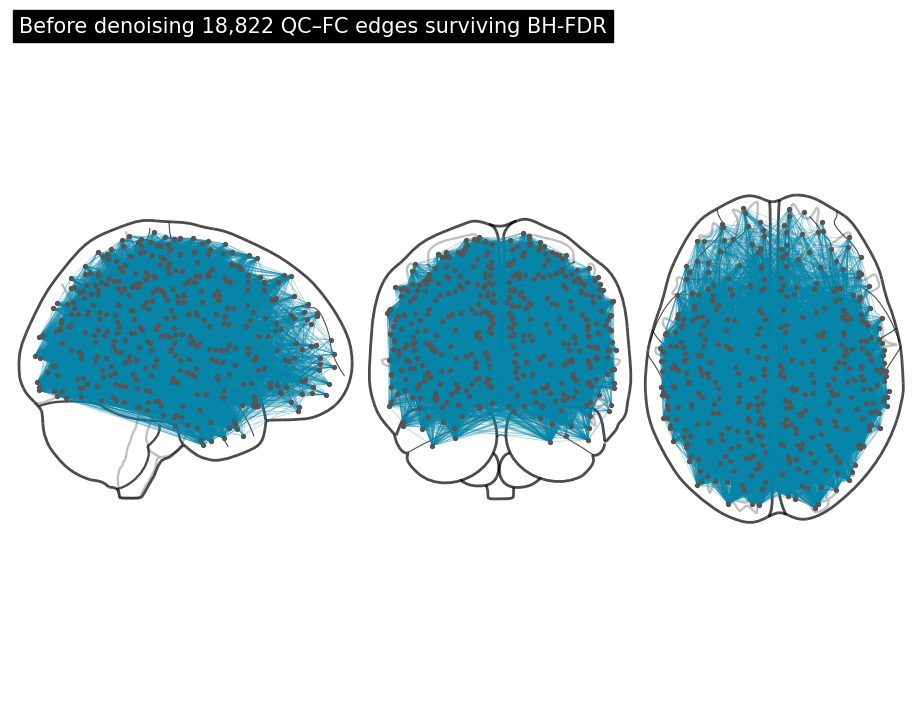

In [7]:
blue_cmap = ListedColormap(["#0785A8"])

fig = plt.figure(figsize=(9, 7))

plotting.plot_connectome(
    adjacency_matrix=binary_significant_matrix,
    node_coords=node_coords,

    # Three-panel view (sagittal/coronal/axial) instead of a single
    # sagittal projection -- a single "x" view collapses left/right
    # hemisphere edges onto the same 2D plane, making the plot look
    # far denser than the true 18,822-edge count.
    display_mode="ortho",

    node_color="#555555",
    node_size=8,

    edge_cmap=blue_cmap,
    edge_vmin=0,
    edge_vmax=1,
    edge_threshold=0,

    edge_kwargs={
        "linewidth": 0.45,
        "alpha": 0.40
    },

    title=(
        "Before denoising "
        f"{n_significant:,} QC–FC edges surviving BH-FDR"
    ),

    annotate=False,
    colorbar=False,
    figure=fig
)

plt.savefig(
    "QCFC_significant_edges_before_denoising.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "QCFC_significant_edges_before_denoising.svg",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

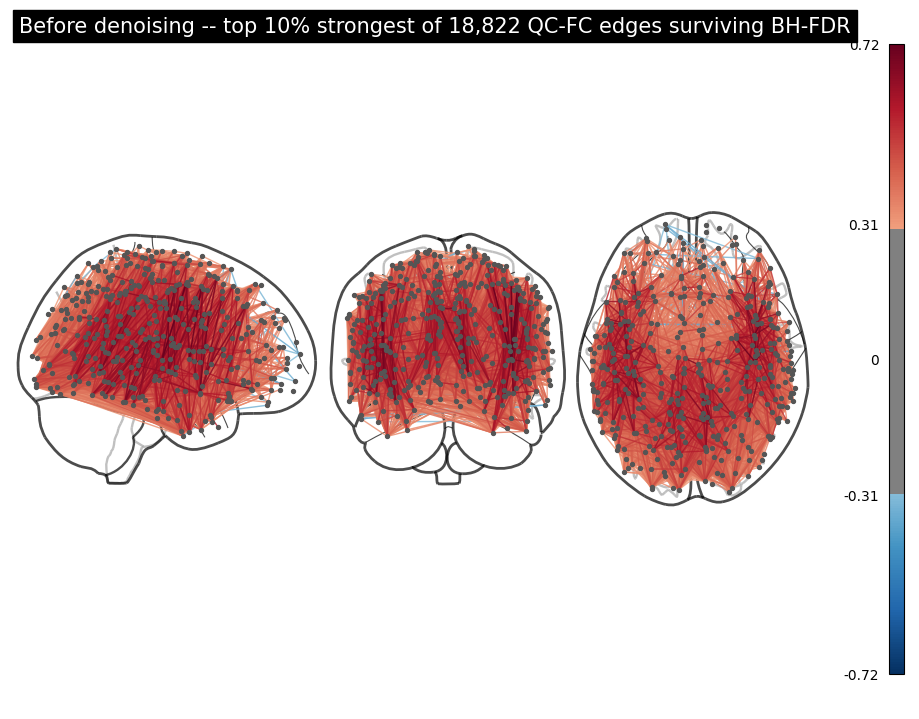

In [8]:
fig2 = plt.figure(figsize=(9, 7))

plotting.plot_connectome(
    adjacency_matrix=significant_r_matrix,
    node_coords=node_coords,

    display_mode="ortho",

    node_color="#555555",
    node_size=8,

    edge_cmap="RdBu_r",
    edge_threshold="90%",

    edge_kwargs={
        "linewidth": 1.0,
        "alpha": 0.85
    },

    title=(
        "Before denoising -- top 10% strongest "
        f"of {n_significant:,} QC-FC edges surviving BH-FDR"
    ),

    annotate=False,
    colorbar=True,
    figure=fig2
)

plt.savefig(
    "QCFC_significant_edges_before_denoising_top10pct.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()